# Title: Tuberculosis (TB) Detection from Chest X-ray using Deep Transfer Learning (PyTorch)
Domain: Medical Imaging

## Introduction:

### Background
Tuberculosis (TB) is a communicable disease which is a major public health problem in Nepal. It is one of 
the top 10 causes of death worldwide and in Nepal, and the leading cause of death from a single infectious 
agent (ranking above HIV/AIDS).

In Nepal, an estimated 69,000 fell ill with TB during FY 2077/78. National Tuberculosis Programme (NTP) 
registered 28,677 (nearly 58% missing vs. the projection) all forms of TB cases (38% female and 62% male). 
Out of 28,677 all forms of TB cases, 28,182 incident TB cases.

> Source : Department of Health Services
2077/78 (2020/21) | Annual Report

### Goal and Objective
The goal of this project is to develop an AI-based solution for detecting tuberculosis from chest X-ray images using transfer learning approach. The solution aims to improve the accuracy and efficiency of TB diagnosis. Aim to use the pre-trained model to detect the signs of TB in chest X-ray images and fine-tune the model to improve the performance. Our solution aims to assist healthcare providers and help in addressing the TB epidemic, particularly in under-served areas where access to healthcare is limited.
Furthermore, the aim is explore the use of GradCAM to provide an insight into the models attention.

### Dataset:
We have used Tuberculosis (TB) Chest X-ray Database to train  and evaluate our model.

#### [Tuberculosis (TB) Chest X-ray Database](https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset)
A team of researchers from Qatar University, Doha, Qatar, and the University of Dhaka, Bangladesh along with their collaborators from Malaysia in collaboration with medical doctors from Hamad Medical Corporation and Bangladesh have created a database of chest X-ray images for Tuberculosis (TB) positive cases along with Normal images. In our current release, there are 700 TB images publicly accessible and 2800 TB images can be downloaded from NIAID TB portal[3] by signing an agreement, and 3500 normal images.

> Tawsifur Rahman, Amith Khandakar, Muhammad A. Kadir, Khandaker R. Islam, Khandaker F. Islam, Zaid B. Mahbub, Mohamed Arselene Ayari, Muhammad E. H. Chowdhury. (2020) "Reliable Tuberculosis Detection using Chest X-ray with Deep Learning, Segmentation and Visualization". IEEE Access, Vol. 8, pp 191586 - 191601. DOI. 10.1109/ACCESS.2020.3031384. Paper Link

In [1]:
# Importing libraries

import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchvision.io import read_image
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from tqdm import tqdm

# Initital configurations
SEED = 1234

def set_seeds(seed=1234):
    """Set seeds for reproducibility."""
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # multi-GPU

# Set seeds for reproducibility
set_seeds(seed=SEED)

# Set device
cuda = True
device = torch.device("cuda" if (
    torch.cuda.is_available() and cuda) else "cpu")

print(device)

cuda


In [2]:
!pip install torchmetrics

## Data preparation:
In this step, we acquired the Tuberculosis (TB) Chest X-ray Database from a reputable source i.e. Kaggle. We then organized the dataset in a directory structure.
```
  - datasets
    |- normal
    |- tuberculosis 

```

Next, we divided the dataset into training, validation and test sets in order to properly train and evaluate our models. This division of dataset is done to ensure that the model is trained on one set of data, validated on another and finally tested on unseen data to evaluate the performance. This helped us to avoid overfitting and generalization of the model.

In [3]:
# Checking excel sheets  and datasets
normal_df = pd.read_excel('../data/TB_Chest_Radiography_Database/Normal.metadata.xlsx')
tuberculosis_df = pd.read_excel('../data/TB_Chest_Radiography_Database/Tuberculosis.metadata.xlsx')

print("-------------------Dataset------------------")
print("Total Normal CXR Images: ",len(normal_df))
print("Total Tuberculosis CXR Images: ",len(tuberculosis_df))

-------------------Dataset------------------
Total Normal CXR Images:  3500
Total Tuberculosis CXR Images:  700


In [4]:
# Splitting the datasets
"""
Here, we have logically divided the datasets into train, valid and test set in 70:15:15 ratio.
And also we have shuffled the dataset, so that both of the categories images gets mixed up.
"""
import glob
normal = glob.glob("../data/TB_Chest_Radiography_Database/Normal/*")
tb = glob.glob("../data/TB_Chest_Radiography_Database/Tuberculosis/*")

# Splitting in 70:15:15 ratio 
train_path = normal[:2450] + tb[:490]
val_path = normal[2450:2975] + tb[490:595]
test_path = normal[2975:] + tb[595:]

# shuffling 
random.shuffle(train_path)
random.shuffle(val_path)
random.shuffle(test_path)

print("-------------------Dataset------------------")
print("Total train CXR Images: ",len(train_path))
print("Total val CXR Images: ",len(val_path))
print("Total test CXR Images: ",len(test_path))

-------------------Dataset------------------
Total train CXR Images:  2940
Total val CXR Images:  630
Total test CXR Images:  630


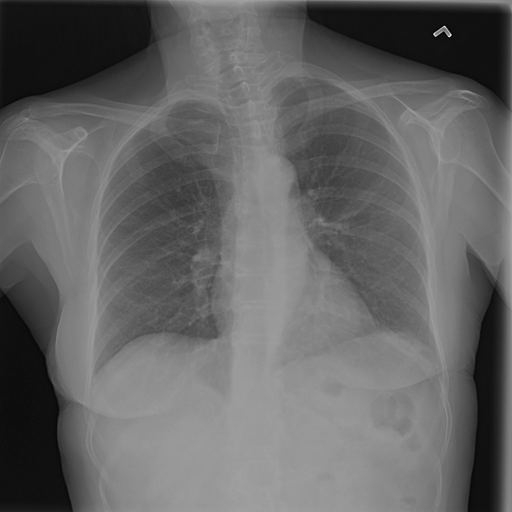

In [5]:
Image.open(train_path[0])

### Preprocessing
In this step, we defined the data preprocessing pipeline for our dataset. We used the PyTorch library's transforms module to perform a series of image transformations on the dataset.

The images are preprocessed by resizing, random rotation, flipping, center cropping, converting to tensors and normalizing using the mean and standard deviation of the dataset. These steps are performed to ensure that all the images are in the same size and format, ready to be input to the model.

In [6]:

data_transforms = {
    'train': transforms.Compose([
        # transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
        transforms.Resize(256),
        transforms.RandomRotation(degrees=15),
        transforms.RandomHorizontalFlip(),
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'others': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


In [7]:
"""
Here, we have defined a custom dataset class 'TB_CXR_Dataset' which takes in a list of image paths 
and an optional transform. The class assigns a label of 0 to images with "normal" in the path and a 
label of 1 for the rest. 

After that, we used this class to create datasets for train, validation, and test data using specific 
transforms for each and created DataLoader objects for each dataset with batch size of 32.

"""
class TB_CXR_Dataset(Dataset):
    def __init__(self, images, transform=None):
        self.img_paths = images
        self.img_labels = [0 if "Normal" in img else 1 for img in self.img_paths]
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        # get the image path and label for the specified index
        img_path = self.img_paths[idx]
        label = self.img_labels[idx]

        # load the image from the path
        image = Image.open(img_path)
        image = image.convert("RGB")

        # apply transform
        if self.transform:
            image = self.transform(image)
        
        # return the image and label as a tuple
        return image, label

# Dataset for train, valid and test
train_data = TB_CXR_Dataset(train_path, transform = data_transforms["train"]) 
valid_data = TB_CXR_Dataset(val_path, transform = data_transforms["others"]) 
test_data = TB_CXR_Dataset(test_path, transform = data_transforms["others"]) 

# Dataloader for train, valid and test
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(valid_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True)

## Data Visualization

In this section, we visualized the distribution of our dataset by plotting a bar graph for , as well as visualizing some images from the dataloader to ensure that they were properly loaded and transformed.

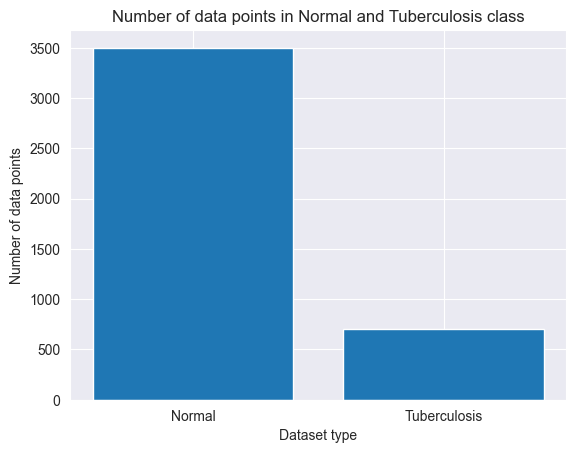

In [8]:
import matplotlib.pyplot as plt
normal_size = len(normal_df)
Tuberculosis_size = len(tuberculosis_df)
sizes = [normal_size, Tuberculosis_size]

plt.bar(['Normal', 'Tuberculosis'], sizes)

plt.xlabel('Dataset type')
plt.ylabel('Number of data points')
plt.title('Number of data points in Normal and Tuberculosis class')

plt.show()

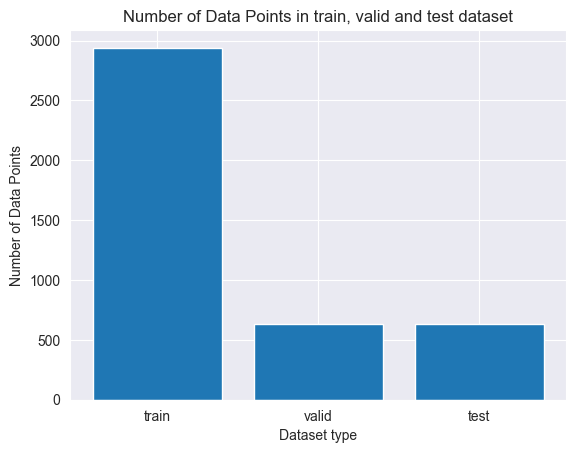

In [9]:
# Get the number of data points in each dataset
train_size = len(train_data)
valid_size = len(valid_data)
test_size = len(test_data) 

# Create a list of the sizes of each dataset
sizes = [train_size, valid_size, test_size]

# Create a bar plot with the sizes of the datasets
plt.bar(['train', 'valid', 'test'], sizes)

# Add labels and title to the plot
plt.xlabel('Dataset type')
plt.ylabel('Number of Data Points')
plt.title('Number of Data Points in train, valid and test dataset')

# Show the plot
plt.show()


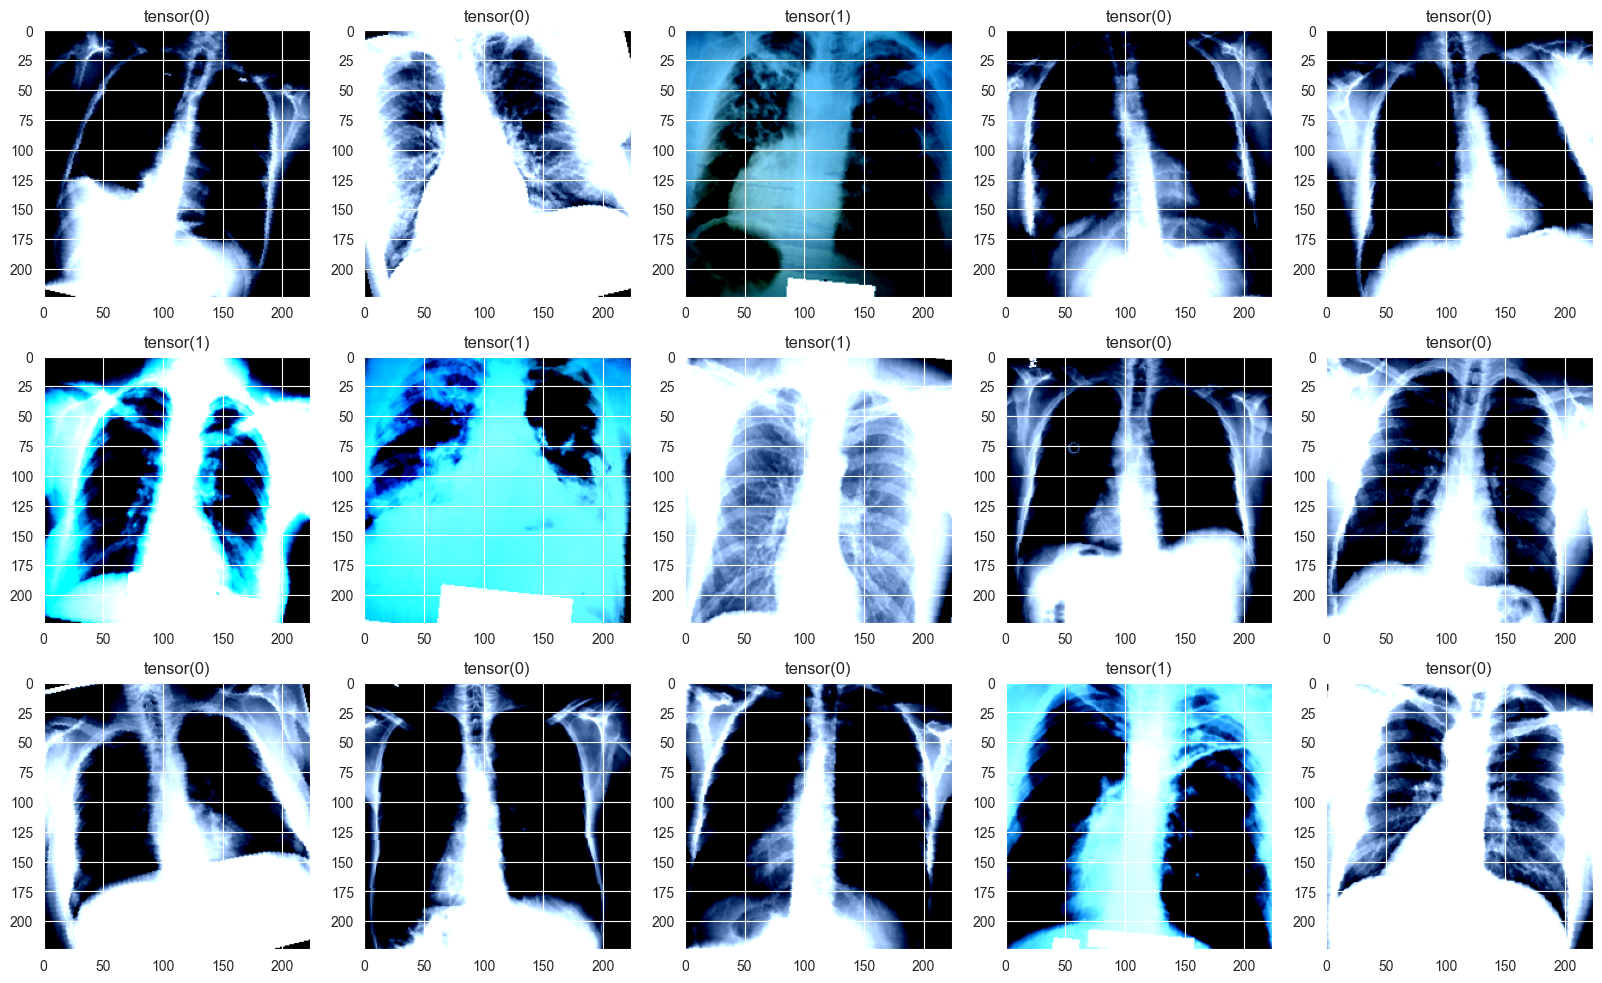

In [10]:
# Load your data using a PyTorch dataloader
data, labels = next(iter(train_dataloader))

# Create a figure with a grid of subplots
fig, axs = plt.subplots(nrows=3, ncols=5,figsize=(20, 12))

# Plot the images in the subplots
for i, ax in enumerate(axs.flat):
    # Get the image and label for the current subplot
    image, label = data[i], labels[i]
    
    # Convert the image to a numpy array and plot it
    img = image.numpy().transpose((1, 2, 0))
    # mean = np.array([0.485, 0.456, 0.406])
    # std = np.array([0.229, 0.224, 0.225])
    # img = std * img + mean
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    
    # Set the title of the subplot to the label
    ax.set_title(label)

# Show the plot
plt.show()

In [11]:
from torchvision.models import densenet121,DenseNet121_Weights, DenseNet
from torchvision.models import vgg19

#model architecture
class CXR_DenseNetModel(nn.Module):
    """DenseNet121 pretrained model definition."""
    def __init__(self, num_classes):
        super(CXR_DenseNetModel, self).__init__()

        self.model = densenet121(pretrained=True)

        # Freeze the model's parameters
        for param in self.model.parameters():
            param.requires_grad = False

        # Replace the last linear layer of the model
        in_features = self.model.classifier.in_features
        self.model.classifier = nn.Sequential(
            nn.Linear(in_features, in_features // 2),
            nn.Dropout(0.5),
            nn.Linear(in_features // 2, in_features // 4),
            # nn.Dropout(0.5),
            nn.Linear(in_features // 4, in_features // 8),
            nn.Dropout(0.25),
            nn.Linear(in_features // 8, num_classes),
        )

    def forward(self, x):
        return self.model(x)

class CXR_DenseNetModel_Finetune(nn.Module):
    """DenseNet121 with option to unfreeze layers for fine-tuning."""
    def __init__(self, num_classes=2, freeze_backbone=True):
        super(CXR_DenseNetModel_Finetune, self).__init__()

        self.model = densenet121(pretrained=True)

        # Optionally freeze the backbone
        if freeze_backbone:
            for param in self.model.parameters():
                param.requires_grad = False

        # Custom classifier
        in_features = self.model.classifier.in_features
        self.model.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.model(x)

    def unfreeze_last_block(self):
        """Unfreeze the last dense block for fine-tuning."""
        for param in self.model.features.denseblock4.parameters():
            param.requires_grad = True
        for param in self.model.features.norm5.parameters():
            param.requires_grad = True
        print("Unfroze denseblock4 and norm5")

    def unfreeze_all(self):
        """Unfreeze entire backbone for full fine-tuning."""
        for param in self.model.parameters():
            param.requires_grad = True
        print("Unfroze entire model")

class TBVGG16Classifier(nn.Module):
    """VGG16-based TB X-ray classifier compatible with pytorch-grad-cam"""

    def __init__(self, num_classes=2, pretrained=True):
        super(TBVGG16Classifier, self).__init__()

        # Load pretrained VGG16
        self.vgg16 = models.vgg16(pretrained=pretrained)

        # Modify the final classifier layer for binary classification (TB vs Normal)
        num_features = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.vgg16(x)

    def get_target_layer(self):
        """Returns the target layer for Grad-CAM visualization"""
        # Last convolutional layer in VGG16
        return self.vgg16.features[-1]

class TBDenseNetClassifier(nn.Module):
    """
    DenseNet121-based TB X-ray classifier compatible with pytorch-grad-cam

    DenseNet is particularly well-suited for medical imaging because:
    - Dense connections promote feature reuse and gradient flow
    - Requires fewer parameters than VGG while being more accurate
    - Used in CheXNet, a state-of-the-art chest X-ray classifier
    """

    def __init__(self, num_classes=2, pretrained=True, densenet_version='121'):
        """
        Args:
            num_classes: Number of output classes (default: 2 for TB/Normal)
            pretrained: Use pretrained ImageNet weights
            densenet_version: '121', '161', '169', or '201'
        """
        super(TBDenseNetClassifier, self).__init__()

        self.densenet_version = densenet_version

        # Load pretrained DenseNet
        if densenet_version == '121':
            self.densenet = models.densenet121(pretrained=pretrained)
        elif densenet_version == '161':
            self.densenet = models.densenet161(pretrained=pretrained)
        elif densenet_version == '169':
            self.densenet = models.densenet169(pretrained=pretrained)
        elif densenet_version == '201':
            self.densenet = models.densenet201(pretrained=pretrained)
        else:
            raise ValueError(f"DenseNet version {densenet_version} not supported. "
                           "Choose from: 121, 161, 169, 201")

        # Get number of input features to the classifier
        num_features = self.densenet.classifier.in_features

        # Replace classifier with custom layer for TB classification
        self.densenet.classifier = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.densenet(x)

    def get_target_layer(self):
        """
        Returns the target layer for Grad-CAM visualization
        For DenseNet, we use the last dense block's norm layer
        """
        # DenseNet's last convolutional layer is in features.denseblock4.denselayer16 (for DenseNet121)
        # But we use the final batch norm layer which gives better visualizations
        return self.densenet.features[-1]  # Final batch norm layer

    def freeze_features(self, freeze_until='all'):
        """
        Freeze feature extraction layers for transfer learning

        Args:
            freeze_until: 'all' - freeze all feature layers
                         'half' - freeze first two dense blocks
                         'none' - freeze nothing
        """
        if freeze_until == 'none':
            return

        if freeze_until == 'all':
            # Freeze all feature layers
            for param in self.densenet.features.parameters():
                param.requires_grad = False

        elif freeze_until == 'half':
            # Freeze first two dense blocks (denseblock1 and denseblock2)
            for name, param in self.densenet.features.named_parameters():
                if 'denseblock1' in name or 'denseblock2' in name:
                    param.requires_grad = False

    def get_model_info(self):
        """Returns information about the model"""
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)

        return {
            'architecture': f'DenseNet-{self.densenet_version}',
            'total_parameters': total_params,
            'trainable_parameters': trainable_params,
            'frozen_parameters': total_params - trainable_params
        }


# model = CXR_DenseNetModel(num_classes=2)
# model=  CXR_DenseNetModel_Finetune(num_classes=2)
# model = TBVGG16Classifier(num_classes=2)
model = TBDenseNetClassifier(num_classes=2)
# set device
model = model.to(device)
model


C:\Users\alexv\anaconda3\envs\safe_xai\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\alexv\anaconda3\envs\safe_xai\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


TBDenseNetClassifier(
  (densenet): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05

In [12]:
# calculating weights for each classes

def class_weight(x,total):
  return 1 - (x/total)

total = 2450 + 490
class_weights = torch.tensor([class_weight(2450,total),class_weight(490,total)])
print(class_weights)

tensor([0.1667, 0.8333])


In [13]:
# Define the Binary CrossEntropy with Logits loss function and Adam optimizer
loss_fn = nn.BCEWithLogitsLoss(weight = class_weights.to(device))
optimizer = optim.Adam(model.parameters(),lr=0.001)

# Decay LR by a factor of 0.1 every 3 epochs
# scheduler = lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [15]:
# Calculate Class Weights
class_0_count = 2450
class_1_count = 490
class_counts = torch.tensor([class_0_count, class_1_count], dtype=torch.float32)
total = class_counts.sum()
# class_weights = total / (2 * class_counts)  # Balanced weights: [0.6, 3.0]

print(f"Class weights: {class_weights}")
print(f"Class 1 gets {class_weights[1]/class_weights[0]:.2f}x more weight\n")

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

# Define loss function and optimizer
loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Loop
def train(model, train_dataloader, valid_dataloader, loss_fn, optimizer,
          num_epochs, device):
    """
    Training loop for DenseNet121 binary classification.
    """
    model = model.to(device)

    # Track history
    train_losses = []
    train_acc = []
    valid_losses = []
    valid_acc = []

    best_valid_acc = 0.0

    for epoch in tqdm(range(num_epochs), desc='Epochs'):
        # Training Phase
        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_dataloader:
            images, labels = images.to(device), labels.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Track metrics
            train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels).item()
            train_total += images.size(0)

        # Calculate training metrics
        train_loss = train_loss / train_total
        train_accuracy = train_correct / train_total
        train_losses.append(train_loss)
        train_acc.append(train_accuracy)

        # Validation Phase
        model.eval()

        valid_loss = 0.0
        valid_correct = 0
        valid_total = 0

        with torch.no_grad():  # No gradient computation
            for images, labels in valid_dataloader:
                images, labels = images.to(device), labels.to(device)

                # Forward pass only
                outputs = model(images)
                loss = loss_fn(outputs, labels)

                # Track metrics
                valid_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                valid_correct += torch.sum(preds == labels).item()
                valid_total += images.size(0)

        # Calculate validation metrics
        valid_loss = valid_loss / valid_total
        valid_accuracy = valid_correct / valid_total
        valid_losses.append(valid_loss)
        valid_acc.append(valid_accuracy)

        # Print results
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}')
        print(f'Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_accuracy:.4f}')

        # Save best model
        if valid_accuracy > best_valid_acc:
            best_valid_acc = valid_accuracy
            torch.save(model.state_dict(), 'best_model.pth')
            print(f'✓ Saved best model (Valid Acc: {best_valid_acc:.4f})')

    print('\n' + '='*60)
    print(f'Training Complete! Best Valid Acc: {best_valid_acc:.4f}')

    return {
        'train_losses': train_losses,
        'train_acc': train_acc,
        'valid_losses': valid_losses,
        'valid_acc': valid_acc
    }
history = train(
    model=model,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    num_epochs=20,
    device=device
)

Class weights: tensor([0.1667, 0.8333])
Class 1 gets 5.00x more weight

Using device: cuda



Epochs:   5%|▌         | 1/20 [00:58<18:28, 58.32s/it]


Epoch 1/20
Train Loss: 0.0158 | Train Acc: 0.9956
Valid Loss: 0.0100 | Valid Acc: 0.9905
✓ Saved best model (Valid Acc: 0.9905)

Epoch 2/20
Train Loss: 0.0090 | Train Acc: 0.9963
Valid Loss: 0.0036 | Valid Acc: 1.0000


Epochs:  10%|█         | 2/20 [02:06<19:12, 64.02s/it]

✓ Saved best model (Valid Acc: 1.0000)


...


Epoch 18/20
Train Loss: 0.0134 | Train Acc: 0.9966
Valid Loss: 0.0150 | Valid Acc: 0.9968


Epochs:  95%|█████████▌| 19/20 [19:49<00:58, 58.96s/it]


Epoch 19/20
Train Loss: 0.0037 | Train Acc: 0.9993
Valid Loss: 0.0105 | Valid Acc: 0.9952


Epochs: 100%|██████████| 20/20 [20:48<00:00, 62.40s/it]


Epoch 20/20
Train Loss: 0.0017 | Train Acc: 0.9997
Valid Loss: 0.0049 | Valid Acc: 0.9984

Training Complete! Best Valid Acc: 1.0000


## Evaluation

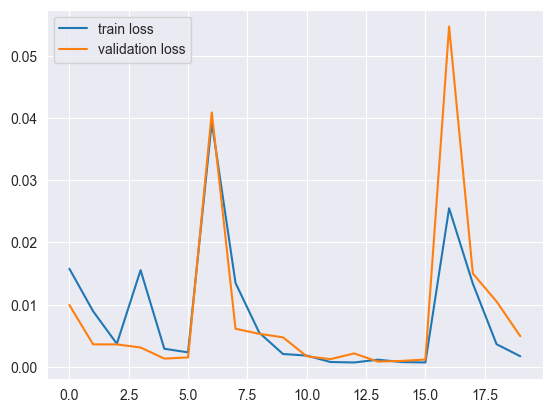

In [16]:
# plot train and test losses

plt.plot(history['train_losses'], label='train loss')
plt.plot(history['valid_losses'], label='validation loss')
plt.legend()
plt.show()

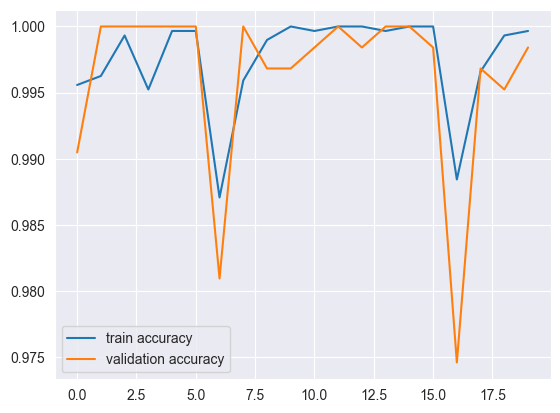

In [17]:
# plot train and test acc
train_acc_np= np.array([x for x in history['train_acc']])
valid_acc_np= np.array([x for x in history['valid_acc']])

plt.plot(train_acc_np, label='train accuracy')
plt.plot(valid_acc_np, label='validation accuracy')
plt.legend()
plt.show()

### Test set evaluation

In [18]:
# Evaluation on test set
y_true = []
y_hat = []

test_size = 0
test_loss = 0.0
test_accuracy = 0.0
# Loop through the testing dataloader
for batch_idx, (images, labels) in enumerate(test_dataloader):
    images, labels = images.to(device), labels.to(device)

    # Zero the gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(images)
    loss = loss_fn(outputs, F.one_hot(labels,2).float())

    # Compute accuracy
    _, preds = torch.max(outputs, 1)
    test_accuracy += torch.sum(preds == labels.data)

    y_true.extend(labels.detach().cpu().numpy().tolist())
    y_hat.extend(preds.detach().cpu().numpy().tolist())

    # Backward pass
    loss.backward()
    optimizer.step()

    test_loss += loss.item() * images.size(0)
    test_size += images.size(0)

In [19]:
import torchmetrics
from torchmetrics.classification import BinaryAccuracy, BinaryAUROC, BinaryF1Score
from mlxtend.plotting import plot_confusion_matrix

metrics_acc = BinaryAccuracy()
metric_auroc = BinaryAUROC(thresholds=None)
metric_f1 = BinaryF1Score()

target = torch.tensor(y_true)
preds = torch.tensor(y_hat)

# Accuracy
acc = metrics_acc(preds, target)

# AUROC
auroc = metric_auroc(preds, target)

# F1 Score
f1 = metric_f1(preds, target)

print("Test Accuracy: ", acc)
print("Test AUROC: ", auroc)
print("Test F1: ", f1)

Test Accuracy:  tensor(0.9984)
Test AUROC:  tensor(0.9990)
Test F1:  tensor(0.9953)


In [20]:
# Classification Report

from sklearn.metrics import classification_report
target_names = ['normal', 'tuberculosis']
print(classification_report(y_true, y_hat, target_names=target_names))

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       525
tuberculosis       0.99      1.00      1.00       105

    accuracy                           1.00       630
   macro avg       1.00      1.00      1.00       630
weighted avg       1.00      1.00      1.00       630



In [21]:
from sklearn.metrics import confusion_matrix

# Order of the input parameters is important: 
# first param is the actual output values
# second param is what our model predicted
conf_matrix = confusion_matrix(y_true, y_hat)

conf_matrix

array([[524,   1],
       [  0, 105]])

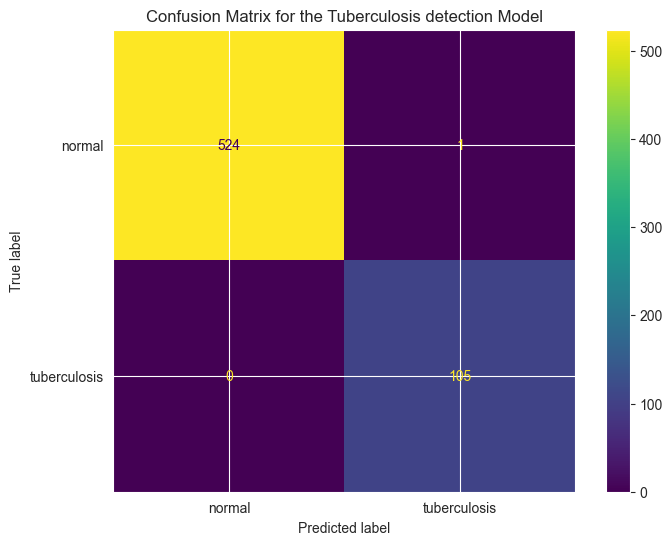

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Change figure size and increase dpi for better resolution
# and get reference to axes object
fig, ax = plt.subplots(figsize=(8,6), dpi=100)

# initialize using the raw 2D confusion matrix 
# and output labels (in our case, it's 0 and 1)
display = ConfusionMatrixDisplay(conf_matrix, display_labels=['normal', 'tuberculosis'],)

# set the plot title using the axes object
ax.set(title='Confusion Matrix for the Tuberculosis detection Model')

# show the plot. 
# Pass the parameter ax to show customizations (ex. title) 
display.plot(ax=ax);

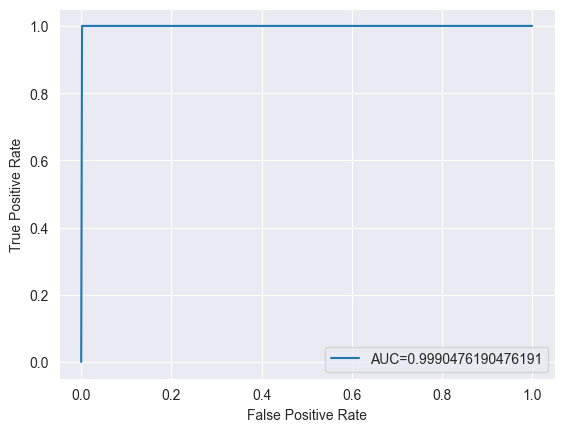

In [23]:
from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(y_true,  y_hat)
auc = metrics.roc_auc_score(y_true, y_hat)

#create ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

# Grad CAM visualizaition (Explainable AI)

In [44]:
from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget, BinaryClassifierOutputTarget,RawScoresOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
import cv2
# from torchvision.models import resnet50
from pprint import pprint
def get_transforms(augment=False):
    """
    Returns preprocessing transforms for DenseNet

    Args:
        augment: If True, includes data augmentation for training
    """
    if augment:
        # Training transforms with data augmentation
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])
    else:
        # Validation/Test transforms (no augmentation)
        return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
        # return transforms.Compose([
        #     transforms.Resize((224, 224)),
        #     transforms.ToTensor(),
        #     transforms.Normalize(mean=[0.485, 0.456, 0.406],
        #                        std=[0.229, 0.224, 0.225])
        # ])

def generate_gradcam(model, img_path, target_class=None, device='cpu'):
    """
    Generate Grad-CAM visualization for an X-ray image

    Args:
        model: Trained TBDenseNetClassifier model
        img_path: Path to the X-ray image
        target_class: Target class for Grad-CAM (None for predicted class)
        device: Device to run on ('cpu' or 'cuda')

    Returns:
        cam_image: Grad-CAM visualization overlaid on original image
        prediction: Model prediction class
        probabilities: Class probabilities
    """
    # Ensure model is on correct device and in eval mode
    model = model.to(device)
    model.eval()

    # Enable gradient computation for the model
    for param in model.parameters():
        param.requires_grad = True

    # Load and preprocess image
    img = Image.open(img_path).convert('RGB')
    img_tensor = get_transforms(augment=False)(img).unsqueeze(0).to(device)
    img_tensor.requires_grad = True

    # Get prediction
    output = model(img_tensor)
    pred = torch.softmax(output, dim=1)
    pred_class = torch.argmax(pred, dim=1).item()

    # Setup Grad-CAM
    target_layer = model.densenet.features.denseblock4.denselayer16.conv2
    cam = GradCAM(model=model, target_layers=[target_layer])

    # Generate CAM
    targets = [target_class] if target_class is not None else None
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    # Overlay on original image
    img_np = np.array(img.resize((224, 224))) / 255.0
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    return cam_image, pred_class, pred[0].detach().cpu().numpy()
# Generate Grad-CAM
tb_img_path = '../data/TB_Chest_Radiography_Database/Tuberculosis/Tuberculosis-200.png'
cam_img, pred_class, probs = generate_gradcam(model, tb_img_path)
print(f"Predicted: {'TB' if pred_class == 1 else 'Normal'}")
print(f"Confidence: {probs[pred_class]*100:.2f}%")

Predicted: TB
Confidence: 100.00%


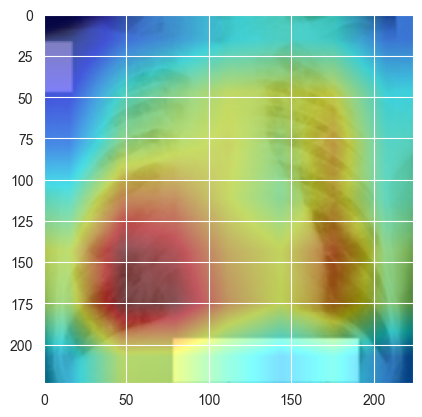

In [45]:
img= Image.fromarray(cam_img)
plt.imshow(cam_img)
img.save('Tb_200.jpeg')

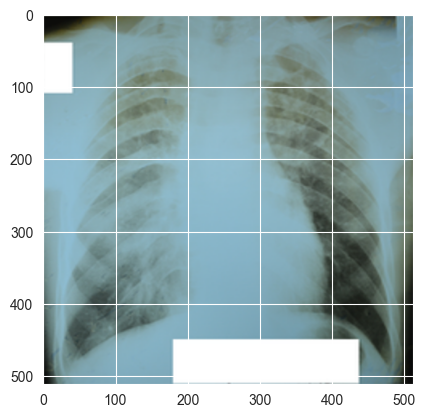

In [47]:
og_img = Image.open(tb_img_path).convert('RGB')
plt.imshow(og_img)
og_img.save('Og_200.jpeg')

Predicted: Normal
Confidence: 100.00%


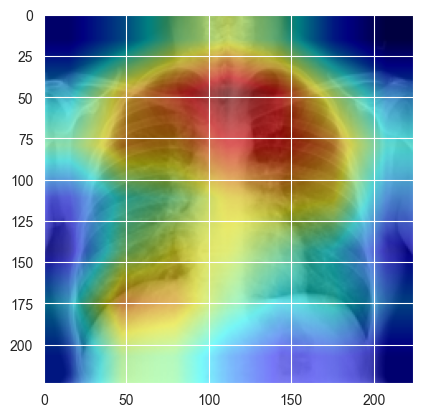

In [59]:
normal_img_path = '../data/TB_Chest_Radiography_Database/Normal/Normal-9.png'
cam_img, pred_class, probs = generate_gradcam(model, normal_img_path)
print(f"Predicted: {'TB' if pred_class == 1 else 'Normal'}")
print(f"Confidence: {probs[pred_class]*100:.2f}%")
img= Image.fromarray(cam_img)
plt.imshow(cam_img)
img.save('Normal_9.jpeg')

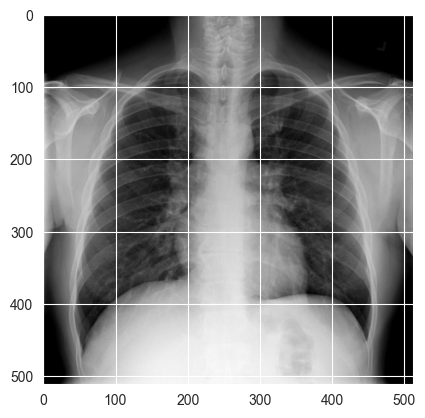

In [61]:
og_img = Image.open(normal_img_path).convert('RGB')
plt.imshow(og_img)
og_img.save('og_9.jpeg')

In [25]:
from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget, BinaryClassifierOutputTarget,RawScoresOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
import cv2
# from torchvision.models import resnet50
from pprint import pprint

# model = CXR_DenseNetModel(num_classes=2)
# best_model = torch.load('best_densenet121.pth', map_location=torch.device('cuda'))
# torchvision.models.densenet121(pretrained=True)
# model.load_state_dict(torch.load('best_densenet121.pth', map_location=torch.device('cuda')))
# pprint(vars(model.model))
# pprint(vars(model.features[-1]))
# print(model.model.classifier[-1].shape)
model = CXR_DenseNetModel_Finetune(num_classes=2)
model.load_state_dict(torch.load('best_densenet121.pth'))
model.eval()
model.to('cpu')
target_layers = [model.model.features.norm5]
print(target_layers)
img = Image.open("../data/TB_Chest_Radiography_Database/Tuberculosis/Tuberculosis-1.png")
img = preprocess_image(img)

print(img.shape)
print(model.model(img).long())
rgb_img = cv2.imread("../data/TB_Chest_Radiography_Database/Tuberculosis/Tuberculosis-1.png", 1)[:, :, ::-1]
print(rgb_img.shape)
rgb_img = cv2.resize(rgb_img, (224,224))
input_tensor = img# Create an input tensor image for your model..
# Note: input_tensor can be a batch tensor with several images!

# We have to specify the target we want to generate the CAM for.
targets = [ClassifierOutputTarget(1)]
pprint(targets)

# Construct the CAM object once, and then re-use it on many images.
# grayscale_cam = GradCAM(model=model.model, target_layers=target_layers,input_tensor=input_tensor, targets=targets)
with GradCAM(model=model.model, target_layers=target_layers) as cam:
  # You can also pass aug_smooth=True and eigen_smooth=True, to apply smoothing.
  grayscale_cam = cam(input_tensor=input_tensor, targets=targets,aug_smooth=True, eigen_smooth=True)
  print(grayscale_cam)
  # In this example grayscale_cam has only one image in the batch:
  grayscale_cam = grayscale_cam[0, :]
  visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
  # You can also get the model outputs without having to redo inference
  model_outputs = cam.outputs

C:\Users\alexv\anaconda3\envs\safe_xai\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\alexv\anaconda3\envs\safe_xai\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


RuntimeError: Error(s) in loading state_dict for CXR_DenseNetModel_Finetune:
	Missing key(s) in state_dict: "model.features.conv0.weight", "model.features.norm0.weight", "model.features.norm0.bias", "model.features.norm0.running_mean", "model.features.norm0.running_var", "model.features.denseblock1.denselayer1.norm1.weight", "model.features.denseblock1.denselayer1.norm1.bias", "model.features.denseblock1.denselayer1.norm1.running_mean", "model.features.denseblock1.denselayer1.norm1.running_var", "model.features.denseblock1.denselayer1.conv1.weight", "model.features.denseblock1.denselayer1.norm2.weight", "model.features.denseblock1.denselayer1.norm2.bias", "model.features.denseblock1.denselayer1.norm2.running_mean", "model.features.denseblock1.denselayer1.norm2.running_var", "model.features.denseblock1.denselayer1.conv2.weight", "model.features.denseblock1.denselayer2.norm1.weight", "model.features.denseblock1.denselayer2.norm1.bias", "model.features.denseblock1.denselayer2.norm1.runnin

In [113]:
pprint(vars(cam))

{'activations_and_grads': <pytorch_grad_cam.activations_and_gradients.ActivationsAndGradients object at 0x0000029860FD6210>,
 'compute_input_gradient': False,
 'detach': True,
 'device': device(type='cuda', index=0),
 'model': CXR_DenseNetModel_Finetune(
  (model): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

In [109]:
grayscale_cam

NameError: name 'grayscale_cam' is not defined